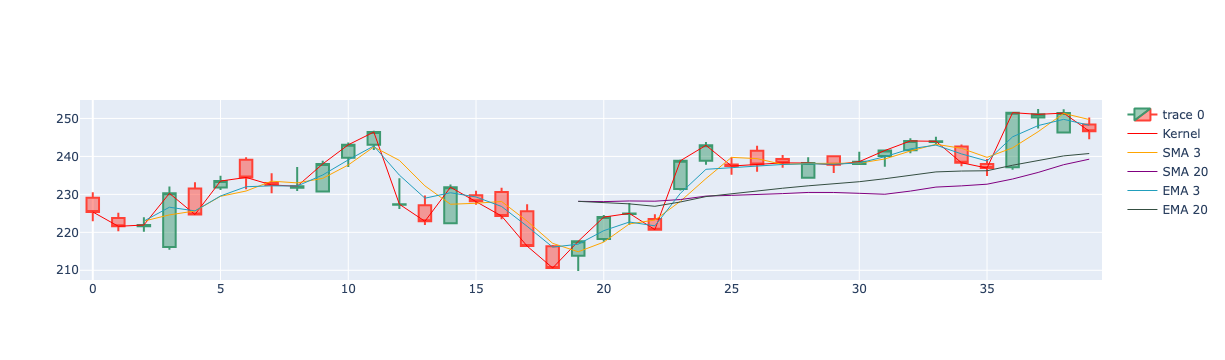

In [17]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from statsmodels.nonparametric.kernel_regression import KernelReg
import pandas_ta as ta
import yfinance as yf

def calculate_kernel_regression(df):
    close_df = df['Close']
    
    #  Use Kernel Regression to create a fitted curve
    bandwidth = 'cv_ls'
    kernel_regression = KernelReg([close_df.values], [close_df.index.to_numpy()], var_type='c', bw=bandwidth)
    regression_result = kernel_regression.fit([close_df.index])
    
    # Get smoothed close prices
    smoothed_prices_df = pd.Series(data=regression_result[0], index=close_df.index)
    return smoothed_prices_df

def calculate_tis(df):
    #  SMA
    df['SMA_3'] = df['Close'].rolling(3).mean()
    df['SMA_20'] = df['Close'].rolling(20).mean()
    #  EMA
    df['EMA_3'] = ta.ema(df['Close'], length=3)
    df['EMA_20'] = ta.ema(df['Close'], length=20)
    return df
    
def create_plot(df, smoothed_prices_df):
    
    import plotly.graph_objects as go  
    
    fig = go.Figure(
        data=[
            go.Candlestick(x=df.index,
                           open=df['Open'],
                           high=df['High'],
                           low=df['Low'],
                           close=df['Close']),
            go.Scatter(x=df.index, y=smoothed_prices_df, line=dict(color='red', width=1), name="Kernel"),
            go.Scatter(x=df.index, y=df['SMA_3'], line=dict(color="orange", width=1), name="SMA 3"),
            go.Scatter(x=df.index, y=df['SMA_20'], line=dict(color="purple", width=1), name="SMA 20"),
            go.Scatter(x=df.index, y=df['EMA_3'], line=dict(color="#219ebc", width=1), name="EMA 3"),
            go.Scatter(x=df.index, y=df['EMA_20'], line=dict(color="#344e41", width=1), name="EMA 20")
        ])
    fig.update_layout(xaxis_rangeslider_visible=False)
    fig.show()

# MAIN
if __name__ == '__main__':

    df = yf.Ticker("MSFT").history("2y", interval="1d")
    df.reset_index(drop=True, inplace=True)
    df=df[0:40]

    if df is None:
        print('Unable to fetch price info')
        exit(0)

    df = calculate_tis(df)
    smoothed_prices_df = calculate_kernel_regression(df)
    #print(smoothed_prices_df)
    create_plot(df, smoothed_prices_df)
    #print(df)